In [1]:
config_path = './src/results/new_design/config.yaml'
import box
import numpy as np; import matplotlib.pyplot as plt # type: ignore
import src.math_tool as mt
import src.img_tool as it
import src.apertures as apertures
import src.load_config as lc
#%load_ext autoreload
#%autoreload 2
#%matplotlib widget
c, π = lc.load(config_path), np.pi
x, y = np.meshgrid(c.sim.xs + c.Δx/2, c.sim.ys + c.Δy/2, indexing='ij') # use center coordinate of pixel
Nθs = 128
orig = np.linspace(0, 2*π, Nθs, endpoint=False, dtype=np.float32)
θ0s = orig[:40]
θ1s = orig[40:80]
θ2s = orig[80:100]
θ3s = orig[100:]

simulation of light at designed focal point passing back to aperture

find phase at aperture of light propagate from a designed focal pattern

In [2]:
# config focal pattern here
x_f_point = np.array([0,0,0, 0,0,0,0, 0,0,0,0,0])
y_f_point = np.array([0,0,0, 0,0,0,0, 0,0,0,0,0]) # N_point
θ_f_point = np.array([0,0,0, 0,0,0,0, 0,0,0,0,0])
magnitude_f_point = np.array([1,1,1,1,1,1,1,1,1,1,1,1]) # focal dist at 35mm
z_f_point = np.array([1,1.01,1.02,1.03, 1.04,1.05,1.06,1.07, 1.08,1.09,1.10,1.11]) * 35e3 # mm

In [3]:
r = mt.dist(x[:, :, None], y[:, :, None], z=0, x_c = x_f_point, y_c=y_f_point, z_c = z_f_point) # Nx, Ny, N_point
# Rayleigh Sommerfeld summation
E = (-1j/c.λ * np.exp(c.k*1j*r)*z_f_point/r**2)@(np.exp(1j*θ_f_point)*magnitude_f_point) # Nx, Ny

1009.07593276096
1843.5560091957223


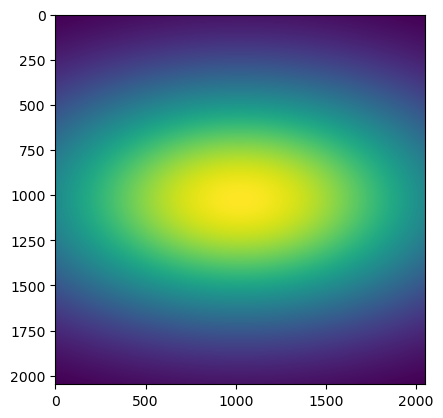

In [4]:
import math 
palldiv = 9.5
perpdiv = 17
lensDist = (2300-1270)+5000
pallBeamWidth = math.tan(math.radians(palldiv))*lensDist
perBeamWidth = math.tan(math.radians(perpdiv))*lensDist
emit = mt.guass(pallBeamWidth, perBeamWidth)
print(pallBeamWidth)
print (perBeamWidth)
Eled = np.sqrt(emit.calc(x,y))    
plt.imshow(Eled)
θ_aperture = np.angle(E)

Ealt = E*Eled
Ealt = Ealt * (np.abs(Eled) > 0.01)
ledDist = mt.dist( x ,y , lensDist,0,0,0)
comp = np.exp(-1j*c.k*ledDist)
theta_Led = np.angle(comp)


In [5]:
θ_aperture = θ_aperture + theta_Led
θ_aperture = θ_aperture * (np.abs(Eled) > 0.01)
print("past")
tmp = θ_aperture[..., None]-θ0s
cos_θ_aperture_θ0s = np.cos(tmp) # Nx, Ny, Nθs
print("past")
# apply constraint of 500μm diameter
aperture_design = (cos_θ_aperture_θ0s > 0)
print("past")
#aperture_design = np.concatenate(aperture_design,(cos_θ_aperture_θ0s[:,:,1024:] > 0))
cosine_similarity =(cos_θ_aperture_θ0s * aperture_design * np.abs(Ealt)[:, :, None]).sum(axis=(0, 1)) # Nθs (range of reference phase)



past
past
past


In [6]:
tmp = θ_aperture[..., None]-θ1s
cos_θ_aperture_θ1s = np.cos(tmp) # Nx, Ny, Nθs
print("past")
# apply constraint of 500μm diameter
aperture_design1 = (cos_θ_aperture_θ1s > 0)
print("past")
#aperture_design = np.concatenate(aperture_design,(cos_θ_aperture_θ0s[:,:,1024:] > 0))
cos_sim_2 = (cos_θ_aperture_θ1s * aperture_design1 * np.abs(Ealt)[:, :, None]).sum(axis=(0, 1))
print("past")

past
past
past


In [7]:
tmp = θ_aperture[..., None]-θ2s
cos_θ_aperture_θ2s = np.cos(tmp) # Nx, Ny, Nθs
print("past")
# apply constraint of 500μm diameter
aperture_design2 = (cos_θ_aperture_θ2s > 0)
print("past")
#aperture_design = np.concatenate(aperture_design,(cos_θ_aperture_θ0s[:,:,1024:] > 0))
cos_sim_3 = (cos_θ_aperture_θ2s * aperture_design2 * np.abs(Ealt)[:, :, None]).sum(axis=(0, 1))
print("past")

past
past
past


In [8]:
tmp = θ_aperture[..., None]-θ3s
cos_θ_aperture_θ3s = np.cos(tmp) # Nx, Ny, Nθs
print("past")
# apply constraint of 500μm diameter
aperture_design3 = (cos_θ_aperture_θ3s > 0)
print("past")
#aperture_design = np.concatenate(aperture_design,(cos_θ_aperture_θ0s[:,:,1024:] > 0))
cos_sim_4 = (cos_θ_aperture_θ3s * aperture_design3 * np.abs(Ealt)[:, :, None]).sum(axis=(0, 1))
print("past")
ccosine_similarity =  np.concatenate((cosine_similarity,cos_sim_2,cos_sim_3,cos_sim_4)) # Nθs (range of reference phase)
caperture_design = np.concatenate((aperture_design,aperture_design1,aperture_design2,aperture_design3),axis = 2 )

past
past
past


In [9]:
# find best possible match over range of reference phase
#                  phase_similarity (Nx, Ny, Nθs)
idx_max = ccosine_similarity.argmax()
idx_min = ccosine_similarity.argmin()
print(ccosine_similarity[idx_min])
print(ccosine_similarity[idx_max])
print(f'min similarity phase / max similarity phase\n{ccosine_similarity[idx_min] / ccosine_similarity[idx_max]}')

34.62756896568379
34.7082968204807
min similarity phase / max similarity phase
0.9976741049779986


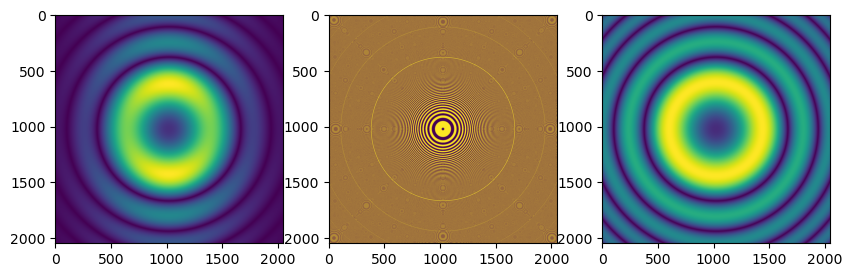

In [10]:
layout = [[0, 1,2]]
fig, ax = plt.subplot_mosaic(layout, figsize=(10,6))
ax[0].imshow(np.abs(Ealt).T) # examine if most high activation region is resolved properly, otherwise may lead to bad reconstruction
ax[1].imshow(caperture_design[..., idx_max].T)
ax[2].imshow(np.abs(E).T)
plt.show()

In [11]:
name = '5fz'
name2 = '26fz'
aperture = caperture_design[..., idx_max]
it.array_2_img(aperture, f'aperture/product/{name}.bmp')
# apreture = np.repeat(apreture, 2, axis=0)
# apreture = np.repeat(apreture, 2, axis=1)
aperture = it.img_pad(aperture, N_pad_xy=(512, 512, 512, 512), pad_val=False)
it.array_2_img(aperture, f'aperture/product/{name2}.bmp')